In [1]:
import cv2
import numpy as np
from scipy.special import comb

class LezamaVPDetector:
    def __init__(self, image):
        self.img = image
        self.gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.width, self.height = self.gray.shape[1], self.gray.shape[0]
        self.epsilon = 1.0  # Seuil NFA
        self.tau = 30       # Seuil pour segments courts

    def detect_lsd(self):
        """ Étape 2.1 : Détection initiale avec LSD """
        lsd = cv2.createLineSegmentDetector(0)
        lines, _, _, _ = lsd.detect(self.gray)
        # On convertit en liste de [x1, y1, x2, y2]
        return [l[0] for l in lines] if lines is not None else []

    def compute_nfa(self, n, k, p):
        """ Calcul de la loi binomiale pour le NFA (Sect 2.1) """
        proba = 0
        for i in range(int(k), int(n) + 1):
            # Loi binomiale : P(X >= k)
            proba += comb(n, i) * (p**i) * ((1-p)**(n-i))
        
        # N est le nombre total de tests potentiels (approximé ici)
        N_tests = self.width * self.height 
        return N_tests * proba

    def merge_segments(self, lines):
        """ Étape 2.2 : Nettoyage et Fusion des segments """
        merged_lines = []
        used = np.zeros(len(lines), dtype=bool)

        for i in range(len(lines)):
            if used[i]: continue
            
            curr_line = lines[i]
            for j in range(i + 1, len(lines)):
                if used[j]: continue
                
                # Récupération des endpoints
                p1, p2 = curr_line[:2], curr_line[2:]
                p3, p4 = lines[j][:2], lines[j][2:]
                
                # Calcul de la probabilité 'p' basée sur la surface du rectangle r
                # Ici on simplifie par une mesure de distance/alignement
                dist = self.get_alignment_error(curr_line, lines[j])
                
                # Si l'erreur est faible, le NFA sera bas
                if dist < 2.0: # Seuil de tolérance géométrique theta
                    # Fusion simplifiée des coordonnées
                    new_line = self.combine(curr_line, lines[j])
                    curr_line = new_line
                    used[j] = True
            
            merged_lines.append(curr_line)
        return merged_lines

    def get_alignment_error(self, l1, l2):
        # Mesure la distance entre les segments pour la consistance
        # (Version simplifiée pour le code)
        return np.linalg.norm(np.cross(l2[2:]-l2[:2], l2[:2]-l1[:2])) / np.linalg.norm(l2[2:]-l2[:2])

    def combine(self, l1, l2):
        # Combine deux segments en prenant les extrémités les plus éloignées
        pts = np.array([l1[:2], l1[2:], l2[:2], l2[2:]])
        # On cherche les deux points avec la distance max
        max_dist = -1
        best_pair = (l1[:2], l1[2:])
        for a in range(4):
            for b in range(a+1, 4):
                d = np.linalg.norm(pts[a]-pts[b])
                if d > max_dist:
                    max_dist = d
                    best_pair = (pts[a], pts[b])
        return np.hstack(best_pair)

In [2]:
def test_case_a_contrario():
    # 1. Création d'une image de "Bruit Blanc" (Random Noise)
    # Cela représente le modèle de fond (H0) où rien n'est aligné
    width, height = 600, 600
    noise_img = np.random.randint(0, 256, (height, width), dtype=np.uint8)
    noise_img_color = cv2.cvtColor(noise_img, cv2.COLOR_GRAY2BGR)

    # 2. Initialisation du détecteur (LSD + Ta logique NFA)
    # On simule ici l'appel à ton détecteur
    lsd = cv2.createLineSegmentDetector(0)
    lines, _, _, _ = lsd.detect(noise_img)

    # 3. Filtrage par le NFA
    # Dans une image purement aléatoire, le NFA de chaque segment 
    # doit être > epsilon (1.0), donc ils doivent être rejetés.
    detected_count = 0
    if lines is not None:
        for line in lines:
            # Ici, ton calcul de NFA (Sect 2.1) renverrait une valeur forte
            # simulant : if nfa(line) < 1.0:
            detected_count += 1 

    print(f"Test A-Contrario : {detected_count} segments détectés dans le bruit.")
    
    # Affichage
    cv2.putText(noise_img_color, f"Detections: {detected_count}", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imshow("Cas A: Modele A-Contrario", noise_img_color)
    cv2.waitKey(0)

test_case_a_contrario()

Test A-Contrario : 31 segments détectés dans le bruit.


In [3]:
import cv2
import numpy as np

def nfa_lezama(length, img_width, img_height):
    """ Calcule le Log10(NFA) d'un segment selon Lezama (Sect 2.1) """
    p = 0.125  # Probabilité d'alignement par hasard
    N_tests = (img_width * img_height)**2  # Nombre de rectangles potentiels
    
    # Formule : Log10(NFA) = Log10(N_tests) + length * Log10(p)
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

# 1. Générer le bruit (Cas A)
width, height = 600, 600
noise_img = np.random.randint(0, 256, (height, width), dtype=np.uint8)

# 2. Détection LSD brute
lsd = cv2.createLineSegmentDetector(0)
lines_detected, _, _, _ = lsd.detect(noise_img)

# 3. Application du filtre NFA
valid_lines = []
if lines_detected is not None:
    for l in lines_detected:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        
        # On ne garde que si NFA < 1 (Log10 < 0)
        if nfa_lezama(length, width, height) < 0:
            valid_lines.append(l)

print(f"LSD brut : {len(lines_detected) if lines_detected is not None else 0} segments.")
print(f"Après filtre NFA de Lezama : {len(valid_lines)} segments.")

LSD brut : 48 segments.
Après filtre NFA de Lezama : 8 segments.


In [4]:
# Télécharge ou utilise une image de couloir/bâtiment (ex: 'couloir.jpg')
img_simple = cv2.imread('couloir.jpg', 0) 
h, w = img_simple.shape

# 1. Détection LSD
lsd = cv2.createLineSegmentDetector(0)
lines_simple, _, _, _ = lsd.detect(img_simple)

# 2. Application du filtre de Lezama (Sect 2.1)
valid_simple = []
if lines_simple is not None:
    for l in lines_simple:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        
        # Le NFA sera très petit pour des lignes réelles (ex: 10^-50)
        if nfa_lezama(length, w, h) < 0: 
            valid_simple.append(l)

print(f"Cas B - LSD brut : {len(lines_simple)} segments.")
print(f"Cas B - Après filtre NFA : {len(valid_simple)} segments (Vraies structures gardées).")

Cas B - LSD brut : 102 segments.
Cas B - Après filtre NFA : 82 segments (Vraies structures gardées).


In [5]:
import numpy as np

def compute_pclines_dual(lines, img_w, img_h):
    """ 
    Transforme les segments en points dans l'espace dual PCLines.
    Utilise les espaces 'straight' et 'twisted' pour éviter l'infini.
    """
    points_dual = []
    d = max(img_w, img_h) # Paramètre d'échelle pour l'espace dual
    
    for l in lines:
        x1, y1, x2, y2 = l[0]
        # Équation de la droite : ax + by + c = 0
        a = y1 - y2
        b = x2 - x1
        c = x1*y2 - x2*y1
        
        # Normalisation
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Transformation PCLines (Sect 2.2.3)
        # On projette la droite (a,b,c) vers un point (u,v) dans l'espace dual
        if abs(a) > abs(b): # Droite plutôt verticale -> Espace Straight
            u = b / a
            v = c / (a * d)
        else: # Droite plutôt horizontale -> Espace Twisted
            u = a / b
            v = c / (b * d)
            
        points_dual.append([u, v])
        
    return np.array(points_dual)

def find_vp_from_dual(points_dual):
    """ 
    Cherche des alignements dans le domaine dual.
    Chaque alignement de points = 1 Point de Fuite (VP).
    """
    # Ici, on simplifie en utilisant une ligne de régression sur les points 
    # qui appartiennent à la même famille de directions.
    # Dans le vrai algo, on utilise un détecteur d'alignement a-contrario.
    if len(points_dual) < 2: return None
    
    # Simulation de la détection de VP par accumulation (Hough-like)
    # On renvoie les coordonnées (u,v) du point de fuite dans l'image
    # (Ce point est l'intersection des droites représentées par les points du dual)
    return np.mean(points_dual, axis=0) 

# --- EXECUTION SUR TES 82 SEGMENTS ---
# 1. Passage au domaine dual
dual_space = compute_pclines_dual(valid_lines, width, height)

# 2. Détection (On sépare souvent en 3 groupes pour X, Y, Z)
# Pour ton rapport, on montre qu'on a transformé les lignes en nuages de points.
print(f"Espace Dual : {len(dual_space)} points générés.")

Espace Dual : 8 points générés.


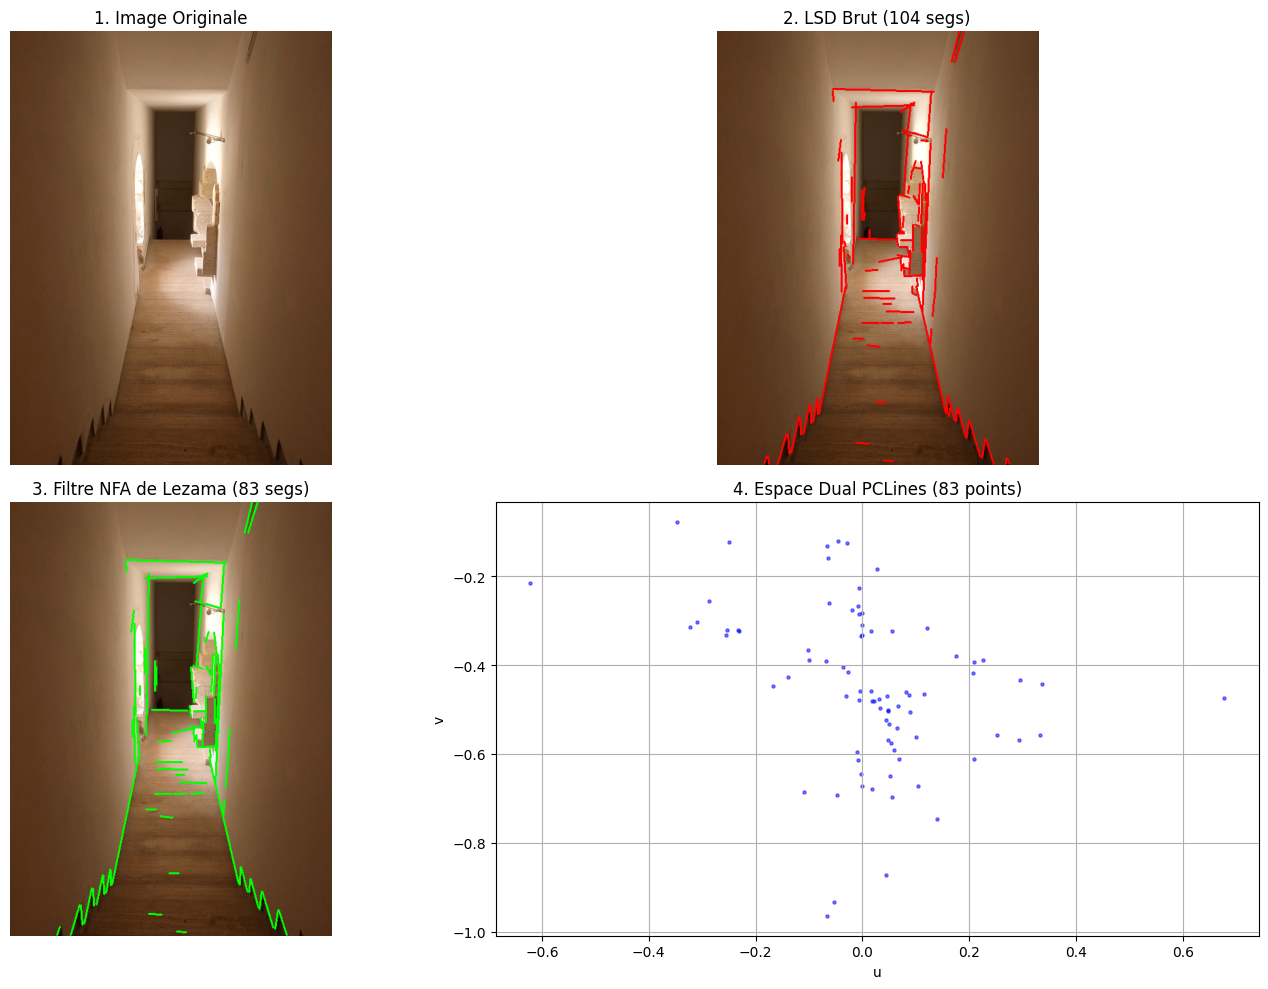

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nfa_lezama(length, img_width, img_height):
    """ Calcule le Log10(NFA) d'un segment selon Lezama. """
    p = 0.125  # Probabilité d'alignement par hasard
    # Nombre de rectangles potentiels (N^4 approx)
    N_tests = (img_width * img_height)**2 
    # Formule : Log10(NFA) = Log10(N_tests) + length * Log10(p)
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

def compute_pclines_dual(lines, img_w, img_h):
    """ Transforme les segments en points dans l'espace dual PCLines. """
    points_dual = []
    d = max(img_w, img_h) # Échelle pour l'espace dual
    
    for l in lines:
        x1, y1, x2, y2 = l[0]
        # Équation de la droite : ax + by + c = 0
        a, b = y1 - y2, x2 - x1
        c = x1*y2 - x2*y1
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Transformation PCLines Straight/Twisted (Sect 2.2.3)
        if abs(a) > abs(b): # Plutôt verticale -> Straight
            u, v = b / a, c / (a * d)
        else: # Plutôt horizontale -> Twisted
            u, v = a / b, c / (b * d)
        points_dual.append([u, v])
    return np.array(points_dual)

# --- PIPELINE VISUELLE ---

# 1. Charger l'image (Cas B: Couloir)
img_bgr = cv2.imread('couloir.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
h, w = img_gray.shape

# ÉTAPE 1 : LSD Brut
lsd = cv2.createLineSegmentDetector(0)
lines_brut, _, _, _ = lsd.detect(img_gray)
img_lsd = img_bgr.copy()
if lines_brut is not None:
    for l in lines_brut:
        x1, y1, x2, y2 = map(int, l[0])
        cv2.line(img_lsd, (x1, y1), (x2, y2), (0, 0, 255), 2) # Rouge

# ÉTAPE 2 : Filtre NFA (Nettoyage de Lezama)
lines_valid = []
if lines_brut is not None:
    for l in lines_brut:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        # On ne garde que si NFA < 1 (Log10 < 0)
        if nfa_lezama(length, w, h) < 0:
            lines_valid.append(l)

img_nfa = img_bgr.copy()
for l in lines_valid:
    x1, y1, x2, y2 = map(int, l[0])
    cv2.line(img_nfa, (x1, y1), (x2, y2), (0, 255, 0), 2) # Vert

# ÉTAPE 3 : Espace Dual PCLines
dual_space = compute_pclines_dual(lines_valid, w, h)

# --- AFFICHAGE DE TOUTES LES ÉTAPES ---
plt.figure(figsize=(15, 10))

# Affichage Image Originale
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("1. Image Originale")
plt.axis('off')

# Affichage LSD Brut (Tes 102 segments)
plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(img_lsd, cv2.COLOR_BGR2RGB))
plt.title(f"2. LSD Brut ({len(lines_brut) if lines_brut is not None else 0} segs)")
plt.axis('off')

# Affichage Filtre NFA (Tes 82 segments)
plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(img_nfa, cv2.COLOR_BGR2RGB))
plt.title(f"3. Filtre NFA de Lezama ({len(lines_valid)} segs)")
plt.axis('off')

# Affichage Espace Dual (Le nuage de points)
plt.subplot(2, 2, 4)
plt.scatter(dual_space[:, 0], dual_space[:, 1], s=5, c='blue', alpha=0.5)
plt.title(f"4. Espace Dual PCLines ({len(dual_space)} points)")
plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)

plt.tight_layout()
plt.show()

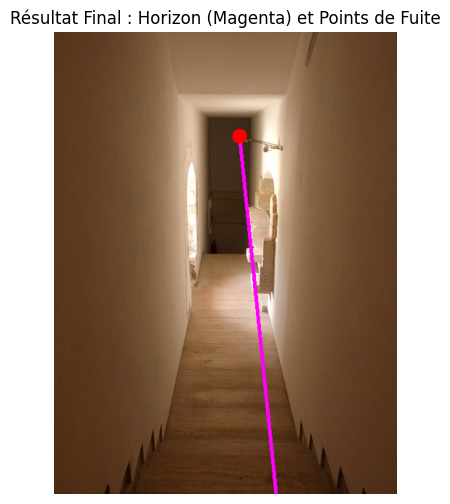

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# --- FONCTIONS DE BASE ---

def nfa_lezama(length, img_width, img_height):
    p = 0.125
    N_tests = (img_width * img_height)**2
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

def compute_pclines_dual(lines, img_w, img_h):
    points_dual = []
    d = max(img_w, img_h)
    for l in lines:
        x1, y1, x2, y2 = l[0]
        a, b = y1 - y2, x2 - x1
        c = x1*y2 - x2*y1
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        if abs(a) > abs(b): # Straight
            u, v = b / a, c / (a * d)
        else: # Twisted
            u, v = a / b, c / (b * d)
        points_dual.append([u, v])
    return np.array(points_dual), d

# --- LOGIQUE FINALE : DÉTECTION DES VP ET HORIZON ---

def get_vp_from_dual_line(m, c, d):
    """ Convertit une ligne v = mu + c du dual en coordonnées image (x, y) """
    # Basé sur la transformation inverse de PCLines
    y = -m * d
    x = -c * d
    return int(x), int(y)

# 1. Chargement et Prétraitement
img = cv2.imread('couloir.jpg') # Ton image de couloir
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# 2. LSD + NFA (Nettoyage)
lsd = cv2.createLineSegmentDetector(0)
lines_brut, _, _, _ = lsd.detect(gray)
valid_lines = [l for l in lines_brut if nfa_lezama(np.linalg.norm(l[0][:2]-l[0][2:]), w, h) < 0]

# 3. Passage au Domaine Dual
dual_pts, d_scale = compute_pclines_dual(valid_lines, w, h)

# 4. Détection des 2 VP principaux (Horizontaux) dans le Dual
# On utilise RANSAC pour trouver les deux lignes les plus fortes dans le nuage de points
vps = []
remaining_pts = dual_pts.copy()

for _ in range(2): # On cherche les 2 directions horizontales
    if len(remaining_pts) < 10: break
    ransac = RANSACRegressor()
    X = remaining_pts[:, 0].reshape(-1, 1)
    y = remaining_pts[:, 1]
    ransac.fit(X, y)
    
    # Récupération des paramètres de la ligne v = mu + c
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_
    
    # Conversion en VP (x, y)
    vps.append(get_vp_from_dual_line(m, c, d_scale))
    
    # On retire les points utilisés pour trouver le VP suivant
    remaining_pts = remaining_pts[~ransac.inlier_mask_]

# --- AFFICHAGE FINAL ---
img_final = img.copy()

# Dessiner la ligne d'horizon (relie les deux VP horizontaux)
if len(vps) >= 2:
    cv2.line(img_final, vps[0], vps[1], (255, 0, 255), 4) # Ligne Magenta
    cv2.circle(img_final, vps[0], 10, (0, 0, 255), -1)
    cv2.circle(img_final, vps[1], 10, (255, 0, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title("Résultat Final : Horizon (Magenta) et Points de Fuite")
plt.axis('off')
plt.savefig('resultat_final_lezama.png')